# **Εργασία 1**
Φοιτητής: Ιατρού Κωνσταντίνος 58071

Καθηγητής: Θεωδορακοπουλος Ηλίας

**Άσκηση 3**

Με στόχο την ταξινόμηση δεδομένων με Bayesian κριτήρια, να εκτελεστούν τα παρακάτω βήματα:

**Ερώτημα α:** Να υλοποιήσετε τρεις συναρτήσεις στη γλώσσα προγραμματισμού της αρεσκείας σας που να υπολογίζουν:


1.   Την τιμή της συνάρτησης διάκρισης g(x) για μία δεδομένη κανονική κατανομή Ν(μ, Σ) d διαστάσεων και εκ των προτέρων πιθανότητα P(ωi).
2.   Την Ευκλείδια απόσταση μεταξύ 2 αυθαίρετων σημείων x1 και x2 σε χώρο d διαστάσεων.
3.   Την απόσταση Mahalanobis μεταξύ του μέσου μ και ενός αυθαίρετου σημείου x σε χώρο d διαστάσεων, δεδομένου του πίνακα συνδιασποράς Σ.




In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from math import sqrt, log, pi

In [10]:
#Ερώτημα α1

def discr_fun(x, m, Sigma, prior):  #x,m,Sigma: float or np.array
    bo = isinstance(m, np.ndarray)    # Για λόγους διαστάσεων πρέπει να γνωρίζουμε στην περίπτωση που είναι
                                      # μονοδιαστατη τιμή για να γίνουν διαφορετικά οι υπολογισμοί γιατι αλλιώς δεν υλοποιούνται στην numpy

    x_m = x-m                         # Υπολογίζω την διαφορά των x και της μέσης τιμή καθώς είναι μία τιμή που θα χρειαστεί αρκετες φορές

    if bo:               # Ελεγχουμε και θα μπούμε στην if μόνο αν προκειται για διανύσματα που βρίσκονται σε χώρο ανω της 1 διάστασης.
                         # Η συνάρτηση len() δεν λειτουργεί για μονοδιάστατες τιμες. Δηλαδή αν x = 0.5 θα εντοπιστεί σφάλμα στην εντολη len(x),
                         # οπότε απλά βλέπουμε αν το bo είναι διάνυσμα τύπου ndarray.
      if len(x) > 1:
        d = len(x)                      # Υπολογίζουμε τις διαστάσεις του χώρου των διανσυμάτων.
        Sigma_inv = np.linalg.inv(Sigma)# Υπολογίζουμε τον αντίστροφο του πίνακα Συνδιασποράς.

        gi = -0.5 * ((x_m).T.dot(Sigma_inv)).dot(x_m) - (d/2)*np.log(2*pi) - 0.5*np.log(abs(np.linalg.det(Sigma))) + np.log(prior)
        # Υπολογίσαμε την τιμή της συνάρτησης διάκρισης ακριβώς όπως μας δίνεται στην εκφώνηση.

      else:
        gi = -0.5 * (x_m).dot(1/Sigma).dot(x_m) - (1/2) * log(2*pi) - 0.5*log(abs(Sigma)) + log(prior)
        # Αφορά μονοδιάστατα διανύσματα πυο είναι της μορφής x = np.ndarray([0.5])
        # Υπολογίσαμε την τιμή της συνάρτησης διάκρισης ακριβώς όπως μας δίνεται στην εκφώνηση, αλλά για τον μονοδιάστατο χώρο,
        # στον οποίο το πρόβλημα είναι πιο απλό καθώς η συνδιασπορά δεν δίνεται από πίνακα, αλλά από μεμονωμένη τιμή.
        # Στην περίπτωση της μίας και μόνο διάστασης το module linalg της numpy δεν λειτουργεί!!!
    else:
      gi = -0.5 * (x_m).dot(1/Sigma).dot(x_m) - (1/2) * log(2*pi) - 0.5*log(abs(Sigma)) + log(prior)
        # Εδώ η διαδικασία είναι για την περιπτωση που το x δοθεί ως float ή integer τιμή. Γενικά να μην δοθεί ως διανυσμα.

    return gi

In [11]:
# Ερώτημα α2
# Γενικά η Εκλειδια απόσταση υπολογίζεται από την ρίζα του αθροισματος των τετραγώνων των διαφορών τον επιμέρους συντεταγμένων κάθε διάστασης
# Δηλαδη στον 2D χώρο τα x = (x1, x2) και y = (y1, y2) έχουν απόσταση ίση με τετραγωνική_ρίζα((x1-y1)^2 + (x2-y2)^2)

def eucl_dist(x1, x2):
  bo = isinstance(x1, list) or isinstance(x1, np.ndarray) # Επειδή στην περίπτωση που τα x1 και x2 μπορεί να ανήκουν σε χώρο μίας διάστασης και
                                                          # ο χρήστης να τα εισάγει ως απλές τιμές και όχι ως μονοδιάστατα διανύσματα πρέπει να
                                                          # ληφθεί υποψη αυτό και να υπάρχει δυνατότητα να γίνει ΚΑΙ αυτός ο υπολογισμός.

  if bo==False:                         # Στην περίπτωση των απλών τιμών απλά θα υπολογιστεί η διαφορά και θα δοθεί η απολυτη τιμή καθώς αυτή
                                        # είναι η ευκλείδια απόσταση σε 1 διάσταση
    distance = abs(x1-x2)
    return distance

  #Απο εδώ και κάτω αφορά εισόδους σε μορφή λίστας ή ndarray

  d = len(x1)     # Για να μάθουμε τα διανύσματα σε χώρο πόσων διαστάσεων βρίσκονται
  distance = 0    # Αρχικοποίηση της απόστασης στο 0

  for i in range(d):
    distance = distance + (x1[i]-x2[i])**2    # Μέσα στο βρόχο γίνεται η άθροιση των τετραγώνων των διαφορών

  return sqrt(distance) # Επιστρέφουμε την ρίζα του αθροισματος των τετραγώνων των διαφορών και ΟΧΙ το ίδιο το άθροισμα


In [12]:
# Ερώτημα α3
# Απόσταση Mahalanobis υπολογιζεται ως το διάνυσμα x-m ανεστραμένο επί τον πίνακα συνδιασποράς επί το διάνυσμ x-m
# και όλος αυτός ο υπολογισμός υψωμένος στο 1/2 (με άλλα λόγια η τετραγωνική ρίζα του)
def Mahalanobis_dist(m, x, Sigma):
  bo = isinstance(m, np.ndarray)    # Οι λόγοι εξηγούνται στο α1
  x_m = x-m
  if bo :
    if len(x)>1:
      Sigma_inv = np.linalg.inv(Sigma) # Υπολογίζουμε τον αντίστροφο του πίνακα Συνδιασποράς.
      dist = x_m.T.dot(Sigma_inv).dot(x_m)[0][0]  # Ο τύπος ακρίβως με αυτόν τον τρόπο δίνεται στην θεωρία.
                                                  # Λείπει μόνο η δύναμη στο 1/2 που θα υπολογιστεί στο τέλος
    else :
      Sigma_inv = 1/Sigma # Ο αντίστροφος του μονοδιάστατου πίνακα συνδιασποράς (ή απλά διασπορά) είναι η αντιστροφη τιμή.
      dist = (x_m**2)*(Sigma_inv) # Οι υπολογισμοί είναι απλοποιούνται όταν προκειται για 1D χώρο.
  else :
    Sigma_inv = 1/Sigma # Αντίστροφο της διασποράς
    dist = (x_m**2)*Sigma_inv # Οι υπολογισμοί είναι απλοποιούνται όταν προκειται για 1D χώρο.

  return sqrt(dist)

**Ερώτημα β:** Το αρχείο δεδομένων *data.csv* που περιέχει δεδομένα από 3 κλάσεις
και τρία χαρακτηριστικά. Υποθέτοντας πως οι υποκείμενες
κατανομές των κλάσεων είναι Gaussian, να κάνετε εκτίμηση των παραμέτρων των
κατανομών με τη μέθοδο της μεγίστης πιθανοφάνειας για τις περιπτώσεις που
χρησιμοποιείται:

1.   μόνο το πρώτο χαρακτηριστικό x1,
2.   το πρώτο και το δεύτερο χαρακτηριστικό (x1 και x2) και
3.   για όλα τα χαρακτηριστικά.


In [13]:
from pandas import read_csv

Αρχικά πρέπει να εισάγουμε τα δεδομένα και να τα χωρίσουμε στις κλάσεις τους.
Θα γίνει η εισαγωγή όλων των χαρακτηριστικών απευθείας και απλά ανάλογα το ερώτημα θα χρησιμοποιώ είτε το πρώτο, είτε το πρώτο και το δεύτερο, είτε όλα.

In [14]:
d = read_csv('data.csv', usecols=[0,1,2])   # Εισάγω τα περιεχόμενα του αρχείου στην μεταβλητή d
c = np.transpose(read_csv('data.csv', usecols=[3]).values)  # Εισάγω στην μεταβλητή c την τέταρτη στήλη που έχει τις τιμές των κλάσεων.
                                                            # Θα τις χρησιμοποιήσω για τον διαχωρισμό των κλάσεων σε ξεχωριστές μεταβλητές.
df = np.transpose(d.values) # Μετατρέπω με αναστροφή του πίνακα με τις τιμές που είχα εισάγει στο d στη μορφή που με βολευει,
                            # για να χωρίσω τα χαρακτηριστικά ανάλογα με την κλάση τους

class_1 = []  # Σε αυτή την λίστα θα μπουν τα δεδομένα της κλάσης 1
class_2 = []  # Σε αυτή την λίστα θα μπουν τα δεδομένα της κλάσης 2
class_3 = []  # Σε αυτή την λίστα θα μπουν τα δεδομένα της κλάσης 3

#Μεσα από την λούπα θα χωρίσουμε τα δεδομένα των κλάσεων με την βοήθεια της c

for i in range(len(df[0])):
  if c[0][i]==1:              # Αν η τιμή της c στην συγκεκριμένη θέση είναι 1, τότε τα στοιχεία της df στην ίδια θέση ανήκουν στην κλάση 1.
    class_1.append([df[0][i], df[1][i], df[2][i]])
  elif c[0][i]==2:            # Αν η τιμή της c στην συγκεκριμένη θέση είναι 2, τότε τα στοιχεία της df στην ίδια θέση ανήκουν στην κλάση 2.
    class_2.append([df[0][i], df[1][i], df[2][i]])
  else:                       # Αν η τιμή της c στην συγκεκριμένη θέση είναι 3, τότε τα στοιχεία της df στην ίδια θέση ανήκουν στην κλάση 3.
    class_3.append([df[0][i], df[1][i], df[2][i]])

# Λίστες θα μετατραπούν σε np.ndarrays γιατί διευκολύνει τις πράξεις διανυσμάτων και πινάκων η βιβλιοθήκη numpy.
class_1 = np.array(class_1)
class_2 = np.array(class_2)
class_3 = np.array(class_3)
print('Class\'s 1 x1 values:\n', class_1)
print('Class\'s 2 x1 values:\n', class_2)
print('Class\'s 3 x1 values:\n', class_3)

Class's 1 x1 values:
 [[  1.6   -0.99   5.83]
 [  6.51   1.19   2.35]
 [ -9.01  -5.3   -2.21]
 [  2.83   1.01   7.12]
 [  0.77  -3.91  -4.31]
 [ -5.4   -4.5    0.77]
 [ -2.08  -3.16   2.25]
 [  0.86   0.98  -1.11]
 [ 13.13   9.06   4.62]
 [ 10.06   7.47  -2.16]
 [ -5.56  -7.29  -7.59]
 [ 11.07   4.66   3.02]
 [  2.31  -4.21   2.47]
 [ -0.68  -5.49   9.63]
 [  2.27  -0.32  -2.84]
 [ -1.22   2.8    0.62]
 [ -0.91  -4.5   -1.66]
 [  5.21   2.48  -7.21]
 [  4.9    0.38  -1.23]
 [  4.93   4.75  -6.31]
 [  2.11  -3.92   2.98]
 [ -5.02  -4.09  -5.86]
 [  2.28   1.5    0.73]
 [  5.74   5.13  -0.74]
 [  1.41   4.25   1.87]
 [  3.48   0.63  -2.16]
 [  2.32  -5.11   1.34]
 [ -1.59  -4.77   1.67]
 [  0.67  -4.59   6.31]
 [ -3.43   4.27  -1.22]
 [  2.93  -1.94  -9.26]
 [ -4.79  -1.65  -5.21]
 [ -4.49  -4.54   3.76]
 [ -3.51  -0.51  -5.76]
 [-11.61 -10.2   -0.26]
 [  5.01  -3.38   0.59]
 [  0.79  -5.7    4.98]
 [ -3.3   -1.7   -9.71]
 [  4.76   0.46  -0.21]]
Class's 2 x1 values:
 [[ -6.93  -5.86  -7

Η συνάρτηση που θα κάνει εκτιμηση παραμέτρων με την Μέθοδο Μέγιστης Πιθανοφάνειας είναι η παρακάτω:

In [15]:
def mle_fun(data):
  mean = np.mean(data, axis=0) # Η συγκεκριμένη συνάρτηση υπολογίζει την μέση τιμή των δεδομένων
                              # Η παράμετρος axis=0 προσδιορίζει ότι θέλω την μέση τιμή τον τιμών που βρίσκονται στην ίδια στήλη.
  cov_matrix = np.cov(data, rowvar=False)  # Η συγκεκριμένη συνάρτηση υπολογίζει το covariance matrix. Η παράμετρος rowvar=False
                                                  # δείχνει στη συνάρτηση ότι κάθε στήλη είναι ξεχωριστή μεταβλητή-χαρακτηριστικό και
                                                  # άρα θα θεωρεί κάθε σειρά μία ξεχωριστή μέτρηση (obseravtion)
  return mean, cov_matrix

Εκτίμηση παραμέτρων μόνο για το χαρακτηριστικό x1:

In [16]:
# Εκτίμηση παραμέτρων για την κλάση 1:
m1_1, s1_1 = mle_fun(class_1[:, 0])
print("Για την κλάση 1:\nμ1 = ", m1_1, "\nσ1^2 = ", s1_1)
print("---------------------------")
# Εκτίμηση παραμέτρων για την κλάση 2:
m2_1, s2_1 = mle_fun(class_2[:, 0])
print("Για την κλάση 2:\nμ2 = ", m2_1, "\nσ2^2 = ", s2_1)
print("---------------------------")
# Εκτίμηση παραμέτρων για την κλάση 3:
m3_1, s3_1 = mle_fun(class_3[:, 0])
print("Για την κλάση 3:\nμ3 = ", m3_1, "\nσ3^2 = ", s3_1)

Για την κλάση 1:
μ1 =  0.9064102564102564 
σ1^2 =  26.65228151147099
---------------------------
Για την κλάση 2:
μ2 =  -1.4842499999999998 
σ2^2 =  38.952850705128206
---------------------------
Για την κλάση 3:
μ3 =  3.6802439024390248 
σ3^2 =  9.45306743902439


Εκτίμηση παραμέτρων για τα χαρακτηριστικά x1 και x2:

In [17]:
# Εκτίμηση παραμέτρων για την κλάση 1:
m1_12, s1_12 = mle_fun(class_1[:, 0:2])
print("Για την κλάση 1:\nμ1 = ", m1_12, "\nΣ1 = \n", s1_12)
print("---------------------------")
# Εκτίμηση παραμέτρων για την κλάση 2:
m2_12, s2_12 = mle_fun(class_2[:, 0:2])
print("Για την κλάση 2:\nμ2 = ", m2_12, "\nΣ2 = \n", s2_12)
print("---------------------------")
# Εκτίμηση παραμέτρων για την κλάση 3:
m3_12, s3_12 = mle_fun(class_3[:, 0:2])
print("Για την κλάση 3:\nμ3 = ", m3_12, "\nΣ3 = \n", s3_12)

Για την κλάση 1:
μ1 =  [ 0.90641026 -1.04487179] 
Σ1 = 
 [[26.65228151 15.823661  ]
 [15.823661   18.38869933]]
---------------------------
Για την κλάση 2:
μ2 =  [-1.48425 -1.14825] 
Σ2 = 
 [[38.95285071  7.96999481]
 [ 7.96999481 11.40803532]]
---------------------------
Για την κλάση 3:
μ3 =  [3.6802439  1.24439024] 
Σ3 = 
 [[9.45306744 6.3758239 ]
 [6.3758239  6.85514024]]


Εκτίμηση παραμέτρων για όλα τα χαρακτηριστικά:

In [18]:
# Εκτίμηση παραμέτρων για την κλάση 1:
m1_123, s1_123 = mle_fun(class_1[:, 0:3])
print("Για την κλάση 1:\nμ1 = ", m1_123, "\nΣ1 = \n", s1_123)
print("---------------------------")
# Εκτίμηση παραμέτρων για την κλάση 2:
m2_123, s2_123 = mle_fun(class_2[:, 0:3])
print("Για την κλάση 2:\nμ2 = ", m2_123, "\nΣ2 = \n", s2_123)
print("---------------------------")
# Εκτίμηση παραμέτρων για την κλάση 3:
m3_123, s3_123 = mle_fun(class_3[:, 0:3])
print("Για την κλάση 3:\nμ3 = ", m3_123, "\nΣ3 = \n", s3_123)

Για την κλάση 1:
μ1 =  [ 0.90641026 -1.04487179 -0.36179487] 
Σ1 = 
 [[26.65228151 15.823661    4.65561444]
 [15.823661   18.38869933 -0.83357476]
 [ 4.65561444 -0.83357476 20.78017827]]
---------------------------
Για την κλάση 2:
μ2 =  [-1.48425 -1.14825 -1.00925] 
Σ2 = 
 [[ 38.95285071   7.96999481 -18.84354801]
 [  7.96999481  11.40803532   0.42592429]
 [-18.84354801   0.42592429  19.70946865]]
---------------------------
Για την κλάση 3:
μ3 =  [3.6802439  1.24439024 1.05609756] 
Σ3 = 
 [[ 9.45306744  6.3758239   9.46632848]
 [ 6.3758239   6.85514024  5.76523256]
 [ 9.46632848  5.76523256 40.60765439]]


**Ερώτημα γ:** Αφού επιλέξτε τον κατάλληλο ταξινομητή (αιτιολογώντας την επιλογή σας) προσδιορίζεται υπολογιστικά το εμπειρικό σφάλμα ταξινόμησης, δηλαδή το ποσοστό των σημείων που ταξινομείται εσφαλμένα, υποθέτωντας ότι οι a priori πιθανότητες είναι P(ω1) = P(ω2) = ½ , κάνοντας χρήση μόνο του πρώτου χαρακτηριστικού x1.

In [19]:
priors = [0.5, 0.5]  # Η τιμή prior για P(ω3) είναι προφανώς άχρηστη. Και για το συγκεκριμένο
                      # ερώτημα θα χρισημοποιηθούν τα δεδομένα μόνο των κλάσεων ω1 και ω2

Θα δημιουργήσω μία συνάρτηση που θα χρησιμοποιεί την συνάρτηση διάκρισης gi (discr_fun()) για να κατατάσσει τα δεδομένα σε κάθε κλάση. Επειδή δεν ζητείται από την άσκηση δεν θα επιστρέφω τις κλάσεις όπως θα διαμορφωνόντουσαν, αλλά μόνο το σφάλμα ταξινόμησης.

In [20]:
# Θα θεωρήσω ότι στον πίνακα με τα δεδομένα που θα εισάγεται ως παράμετρος εισόδου,
# στην τελευταία στήλη θα υπάρχουν οι σωστές κλάσεις. Έτσι θα μπορώ να συγκρίνω άμεσα
# την απάντηση του ταξινομητή με την πραγματική και να βγάλω ένα τελικό σφάλμα.

def classify_fun(observations, feature_num, num_of_classes, classes_mean, classes_sigma, priors):
  #discr_fun(x, m, Sigma, prior)
  errors = 0
  num_of_obersvations = len(observations)                                           # Βλέπω τον συνολικό αριθμό των δειγμάτων που πρέπει να ταξινομηθούν
  print("Ο αριθμός των δεδομένων προς τα ξινόμηση είναι: ", num_of_obersvations)    # Με αυτόν τον αριθμό θα διαιρέσω τον συνολικό αριθμό των λάθων αποφάσεων
                                                                                    # για να υπολογισω το εμπειρικο σφαλμα ταξινόμησης

  for i in range(num_of_obersvations):                                              # Για κάθε δεδομένο πρέπει να υπολογιστούν δύο τιμές g1 και g2 (Επειδη 2 είναι οι κλάσεις)
    gi = []                                                                         # Οποια τιμή είναι μεγαλύτερη το δεδομένο θα ταξινομηθεί σε εκεινη την κλάση

    for j in range(num_of_classes):
      d1 = discr_fun(observations[i, 0:feature_num], classes_mean[j], classes_sigma[j], priors[j])  #Υπολογίζει το gj και το κάνει append στον πίνακα που κράτάει το g1 και το g2.
      gi.append(d1)

    if gi.index(max(gi))+1!=observations[i][-1]:              # Τσεκάρει ποιο index έχει την μεγαλύτερη τιμή. Το +1 παίζει τον ρόλο ότι στην θέση 0 έχουμε το g1 και στην θέση 2 έχουμε το g2
                                                              # Άρα για να συγκρίνουμε το index του μεγαλύτερου gi με την πραγματική κλάση, πρέπει να προσθέσουμε 1 στην τιμή του index.
      errors = errors + 1                                     # Αυξάνουμε τον αριθμό τον λάθων ταξινομήσεων κατά αν μπει μεσα στην if, δηλαδή αν το index+1 δεν είναι ίσο με τον αριθμό της σωστής κλάσης.

  classifications_error = errors/num_of_obersvations

  return classifications_error

In [21]:
observations_to_classify = np.column_stack((df.T[:79, 0], c.T[:79]))  # Παίρνω μόνο τα δεδομένα για το χαρακτηριστικό 1 και μόνο των κλάσεων 1 και 2
#print(observations_to_classify)

In [22]:
means_1feature = np.array([m1_1, m2_1])   # Δημιουργώ μία λιστα με τις μέσες τιμές για το χαρακτηριστικό 1 για κάθε κλάση.
                                          # Επειδή υπολογίστηκαν οι τιμές πριν, δεν τις ξαναυπολογίζω
sigmas_1feature = np.array([s1_1, s2_1])  # Ομοίως για την διασπορά, όπως έγινε για τις μέσες τιμές στην προηγούμενη γραμμή.

In [26]:
print("Το εμπειρικό σφάλμα τα ξινόμησης είναι: ", classify_fun(observations_to_classify, 1, 2, means_1feature, sigmas_1feature, priors))

Ο αριθμός των δεδομένων προς τα ξινόμηση είναι:  79
Το εμπειρικό σφάλμα τα ξινόμησης είναι:  0.4050632911392405


Χρησιμοποιώντας τα πρώτα 2 χαρακτηριστικά x1 και x2:

In [27]:
observations_to_classify = np.column_stack((df.T[:79, 0:2], c.T[:79]))  # Παίρνω μόνο τα δεδομένα για τα χαρακτηριστικά 1 και 2 και μόνο των κλάσεων 1 και 2
#print(observations_to_classify)

In [28]:
means_2features = np.array([m1_12, m2_12])   # Δημιουργώ μία λιστα με τις μέσες τιμές για το χαρακτηριστικό 1 για κάθε κλάση.
                                          # Επειδή υπολογίστηκαν οι τιμές πριν, δεν τις ξαναυπολογίζω
sigmas_2features = np.array([s1_12, s2_12])  # Ομοίως για την διασπορά, όπως έγινε για τις μέσες τιμές στην προηγούμενη γραμμή.

In [30]:
print("Το εμπειρικό σφάλμα ταξινόμησης είναι: ", classify_fun(observations_to_classify, 2, 2, means_2features, sigmas_2features, priors))

Ο αριθμός των δεδομένων προς τα ξινόμηση είναι:  79
Το εμπειρικό σφάλμα ταξινόμησης είναι:  0.379746835443038


Χρησιμοποιώντας όλα τα χαρακτηριστικά:

In [31]:
observations_to_classify = np.column_stack((df.T[:79, 0:3], c.T[:79]))  # Παίρνω μόνο τα δεδομένα για ολα τα χαρακτηριστικά, μόνο των κλάσεων 1 και 2
means_2features = np.array([m1_123, m2_123])    # Δημιουργώ μία λιστα με τις μέσες τιμές για όλα τα χαρακτηριστικα για κάθε κλάση.
                                              # Επειδή υπολογίστηκαν οι τιμές πριν, δεν τις ξαναυπολογίζω
sigmas_2features = np.array([s1_123, s2_123])   # Ομοίως για την διασπορά, όπως έγινε για τις μέσες τιμές στην προηγούμενη γραμμή.

In [32]:
print("Το εμπειρικό σφάλμα τα ξινόμησης είναι: ", classify_fun(observations_to_classify, 3, 2, means_2features, sigmas_2features, priors))

Ο αριθμός των δεδομένων προς τα ξινόμηση είναι:  79
Το εμπειρικό σφάλμα τα ξινόμησης είναι:  0.21518987341772153


Ο λόγος που μειώνεται το σφάλμα από το 1 χαρακτηριστικό στα 2, είναι γιατί στην ουσία όταν χρησιμοποιούμε 1 χαρακτηριστικό οι 2 κλάσεις βρίσκονται σε 1 διάσταση και ο διαχωρισμός είναι σχετικά δύσκολος.

Όταν προσθέτουμε και το 2ο χαρακτηριστικό το πρόβλημα της ταξινόμησης πηγαίνει σε έναν χώρο 2 διαστάσεων και  γίνεται πιο διακριτός ο διαχωρισμός των 2 κλάσεων.

Το σφάλμα όπως φαίνεται μειώνεται ακόμα περισσότερο όταν χρησιμοποιούμε και τα 3 χαρακτηριστικά.

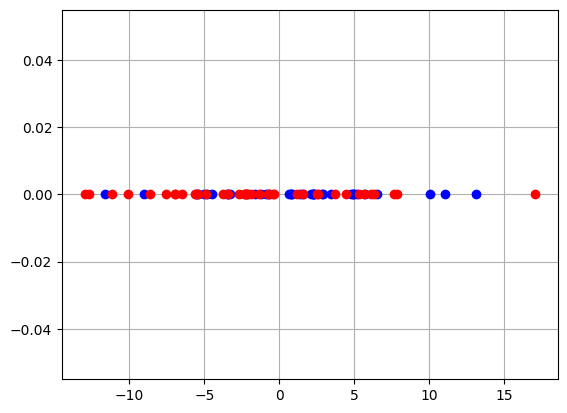

In [33]:
plt.plot(class_1[: , 0], np.zeros(len(class_1[:, 0])), 'o', color='blue')
plt.plot(class_2[: , 0], np.zeros(len(class_2[:, 0])), 'o', color='red')
plt.grid()
plt.show()

# Είναι φανερό πως τότε η διάκριση θα είναι πολύ δύσκολη μέ ένα χαρακτηριστικό και μόνο.

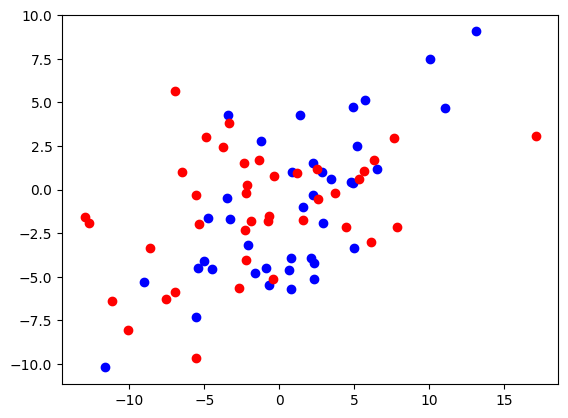

In [34]:
# fig = plt.figure()
# ax = plt.axes(projection='3d')
# ax.grid()

plt.plot(class_1[:, 0], class_1[:, 1], 'o', color='blue')
plt.plot(class_2[:, 0], class_2[:, 1], 'o', color='red')
plt.show()

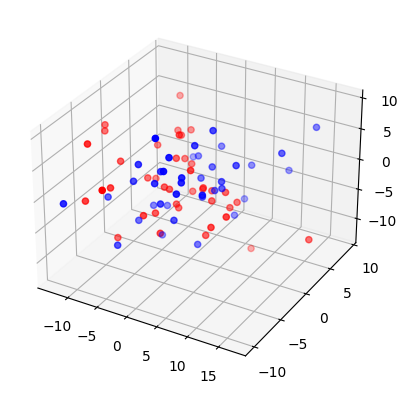

In [35]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.grid()

ax.scatter(class_1[:, 0], class_1[:, 1], class_1[:, 2], color='blue')
ax.scatter(class_2[:, 0], class_2[:, 1], class_2[:, 2], color='red')
plt.show()

In [36]:
priors = [0.8, 0.1, 0.1]
observations_to_classify = np.column_stack((df.T[:, 0:3], c.T[:]))  # Παίρνω μόνο τα δεδομένα για ολα τα χαρακτηριστικά, μόνο των κλάσεων 1 και 2
means_2features = np.array([m1_123, m2_123, m3_123])    # Δημιουργώ μία λιστα με τις μέσες τιμές για όλα τα χαρακτηριστικα για κάθε κλάση.
                                              # Επειδή υπολογίστηκαν οι τιμές πριν, δεν τις ξαναυπολογίζω
sigmas_2features = np.array([s1_123, s2_123, s3_123])   # Ομοίως για την διασπορά, όπως έγινε για τις μέσες τιμές στην προηγούμενη γραμμή.

print("Το εμπειρικό σφάλμα τα ξινόμησης είναι: ", classify_fun(observations_to_classify, 3, 3, means_2features, sigmas_2features, priors))

Ο αριθμός των δεδομένων προς τα ξινόμηση είναι:  120
Το εμπειρικό σφάλμα τα ξινόμησης είναι:  0.55
